<a href="https://colab.research.google.com/github/LakshayRana-7/collab/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#regression Modle
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
#evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv(r"/content/house_price_regression_dataset - house_price_regression_dataset.csv")

print(df.head())

   Square_Footage  Num_Bedrooms  ...  Neighborhood_Quality   House_Price
0            1360             2  ...                     5  2.623829e+05
1            4272             3  ...                     6  9.852609e+05
2            3592             1  ...                     9  7.779774e+05
3             966             1  ...                     8  2.296989e+05
4            4926             2  ...                     8  1.041741e+06

[5 rows x 8 columns]


In [ ]:
print(df.columns.tolist())

['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']


In [ ]:
TARGET_COLUMNS = "House_Price"
x= df.drop(TARGET_COLUMNS, axis=1)
y= df[TARGET_COLUMNS]
print(x.head())
print(y.head())

   Square_Footage  Num_Bedrooms  ...  Garage_Size  Neighborhood_Quality
0            1360             2  ...            0                     5
1            4272             3  ...            1                     6
2            3592             1  ...            0                     9
3             966             1  ...            1                     8
4            4926             2  ...            0                     8

[5 rows x 7 columns]
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [ ]:
x = pd.get_dummies(x , drop_first=True)

In [ ]:
x_train, x_test, y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,

)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model = {
    "Linear Regression":LinearRegression(),
    "Ridge Regression" : Ridge(),
    "lasso Regression" : Lasso(),
    "KNN Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest " : RandomForestRegressor(random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(random_state=42),
    "Extra Tree": ExtraTreesRegressor(random_state=42),
    "AdaBoost" : AdaBoostRegressor(random_state=42),
    "SVR" : SVR()


}

In [ ]:
results= []
for name, regressor in model.items():
  if name in [    "Linear Regression",    "Ridge Regression" ,    "lasso Regression" ,    "KNN Regressor" ,"SVR" ] :
    regressor.fit(x_train_scaled, y_train)
    pred = regressor.predict(x_test_scaled)
  else :
    regressor.fit(x_train,y_train)
    pred= regressor.predict(x_test)

  mae = mean_absolute_error(y_test,pred)
  mse = mean_squared_error(y_test,pred)
  rmse = np.sqrt(mse)
  r2=r2_score(y_test, pred)
  results.append([name,mae,mse,rmse , r2])
  print(results)


[['Linear Regression', 8174.583599930547, 101434798.4530505, np.float64(10071.484421526477), 0.9984263636831646]]
[['Linear Regression', 8174.583599930547, 101434798.4530505, np.float64(10071.484421526477), 0.9984263636831646], ['Ridge Regression', 8241.586909949356, 102480989.96052483, np.float64(10123.289483192942), 0.9984101333068477]]
[['Linear Regression', 8174.583599930547, 101434798.4530505, np.float64(10071.484421526477), 0.9984263636831646], ['Ridge Regression', 8241.586909949356, 102480989.96052483, np.float64(10123.289483192942), 0.9984101333068477], ['lasso Regression', 8174.748373738497, 101436558.1275155, np.float64(10071.571780388376), 0.9984263363839766]]
[['Linear Regression', 8174.583599930547, 101434798.4530505, np.float64(10071.484421526477), 0.9984263636831646], ['Ridge Regression', 8241.586909949356, 102480989.96052483, np.float64(10123.289483192942), 0.9984101333068477], ['lasso Regression', 8174.748373738497, 101436558.1275155, np.float64(10071.571780388376), 0.

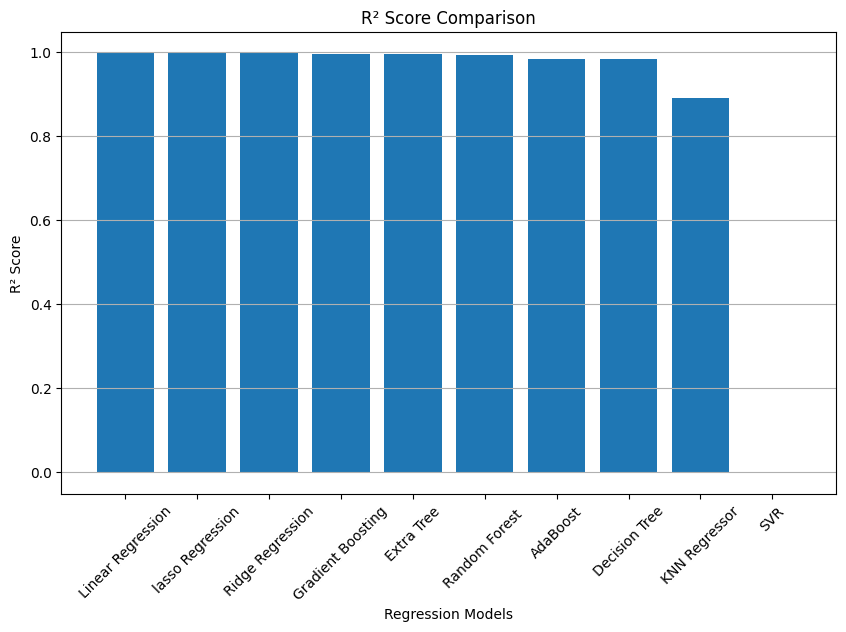

In [ ]:
import matplotlib.pyplot as plt

# Sort by R² Score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(results_df["model1"], results_df["R2 Score"])
plt.title("R² Score Comparison")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

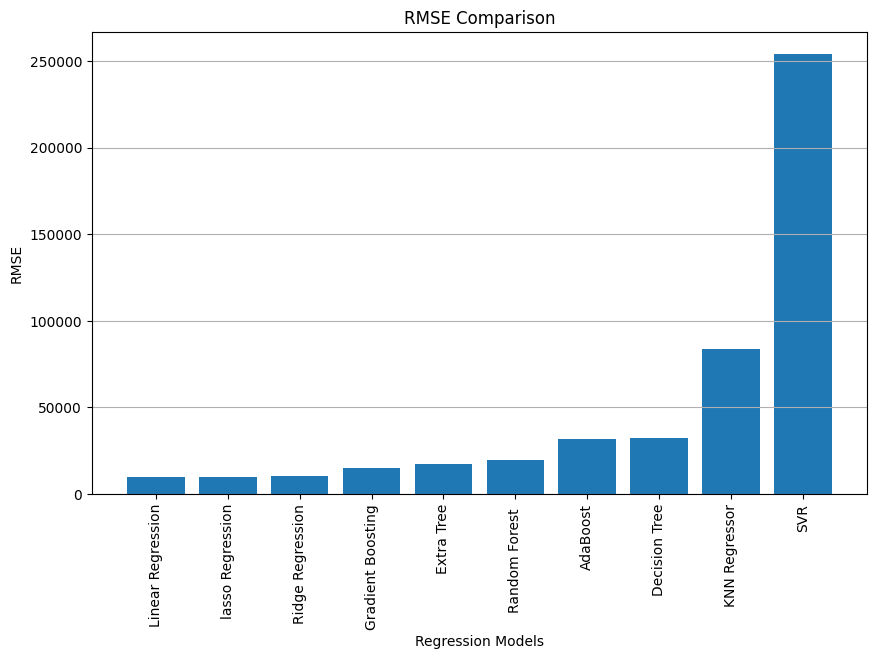

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["model1"], results_df["rmse"])
plt.title("RMSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

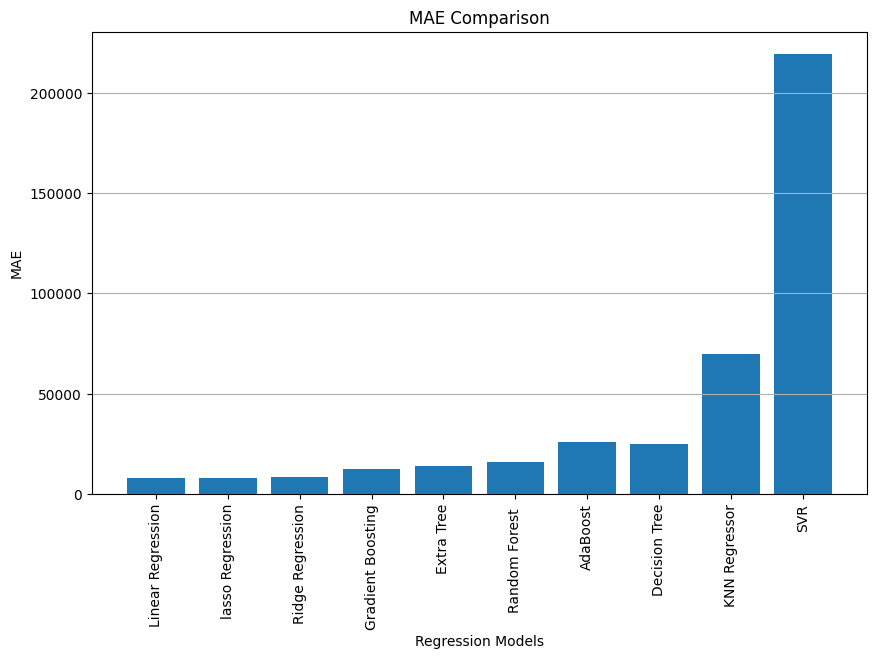

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["model1"], results_df["mae"])
plt.title("MAE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MAE")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

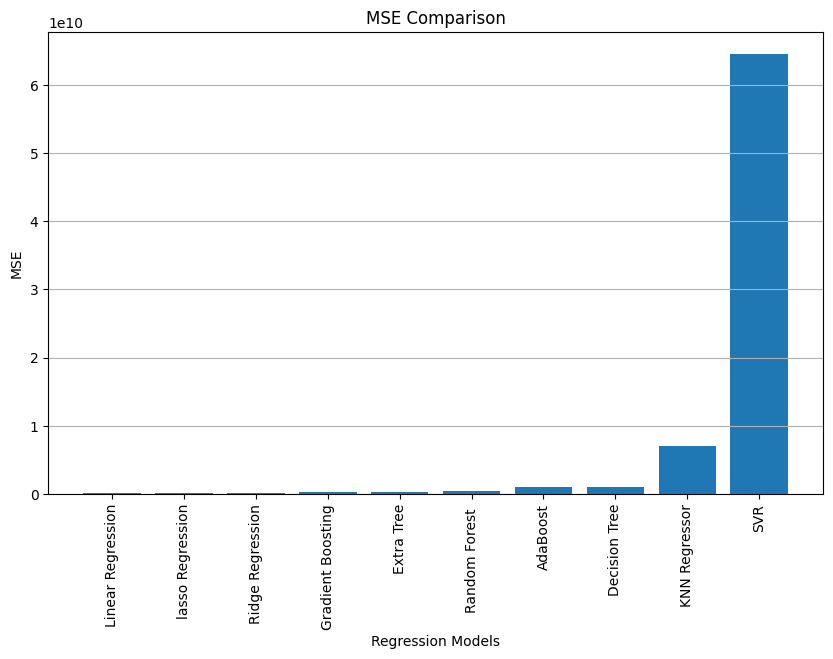

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["model1"], results_df["mse"])
plt.title("MSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MSE")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

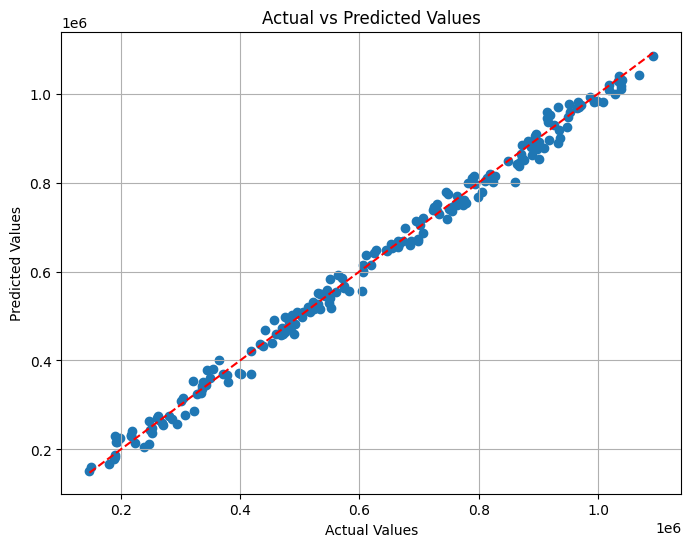

In [ ]:
best_model = RandomForestRegressor(random_state=42)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()